# Random walk e diffusione

Qui analizziamo i dati generati con un codice C che mostra la distribuzione di probabilità $P(x - x_0)$ mediata su molte traiettorie, al variare del numero di passi compiuti.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE_FOLDER = Path("../../../CODICI/RANDOM_WALK")

files = {
    10: BASE_FOLDER / "prob_10.dat",
    100: BASE_FOLDER / "prob_100.dat",
    1000: BASE_FOLDER / "prob_1000.dat",
}

In [2]:
def load_probability_file(path):
    # Legge un file con colonne x e P(x), normalizzando la distribuzione.
    data = np.loadtxt(path, comments="#")

    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] < 2:
        raise ValueError(
            f"{path} deve contenere almeno due colonne: x e P(x)."
        )

    x = data[:, 0]
    probability = data[:, 1]

    order = np.argsort(x)
    x = x[order]
    probability = probability[order]

    if np.any(probability < 0):
        raise ValueError(f"{path} contiene probabilità negative.")

    normalization = probability.sum()
    if normalization <= 0:
        raise ValueError(f"{path} non contiene una distribuzione valida.")

    probability = probability / normalization
    return x, probability


def discrete_moments(x, probability):
    mean = np.sum(x * probability)
    variance = np.sum((x - mean) ** 2 * probability)
    return mean, variance


def lattice_spacing(x):
    differences = np.diff(np.unique(x))
    positive = differences[differences > 0]

    if positive.size == 0:
        raise ValueError("Servono almeno due valori distinti di x.")

    return np.median(positive)


def gaussian_probability_mass(x, mean, variance, dx):
    density = np.exp(-0.5 * (x - mean) ** 2 / variance)
    density /= np.sqrt(2 * np.pi * variance)
    return density * dx

In [3]:
distributions = {}

for n_steps, path in files.items():
    x, probability = load_probability_file(path)
    mean, variance = discrete_moments(x, probability)
    dx = lattice_spacing(x)

    distributions[n_steps] = {
        "x": x,
        "probability": probability,
        "mean": mean,
        "variance": variance,
        "dx": dx,
    }

    print(
        f"n = {n_steps:4d} | "
        f"somma P = {probability.sum():.8f} | "
        f"media = {mean:.6g} | "
        f"varianza = {variance:.6g} | "
        f"Delta x = {dx:.6g}"
    )

n =   10 | somma P = 1.00000000 | media = 0.01428 | varianza = 10.0142 | Delta x = 2
n =  100 | somma P = 1.00000000 | media = -0.02948 | varianza = 99.7719 | Delta x = 2
n = 1000 | somma P = 1.00000000 | media = 0.10528 | varianza = 997.575 | Delta x = 2


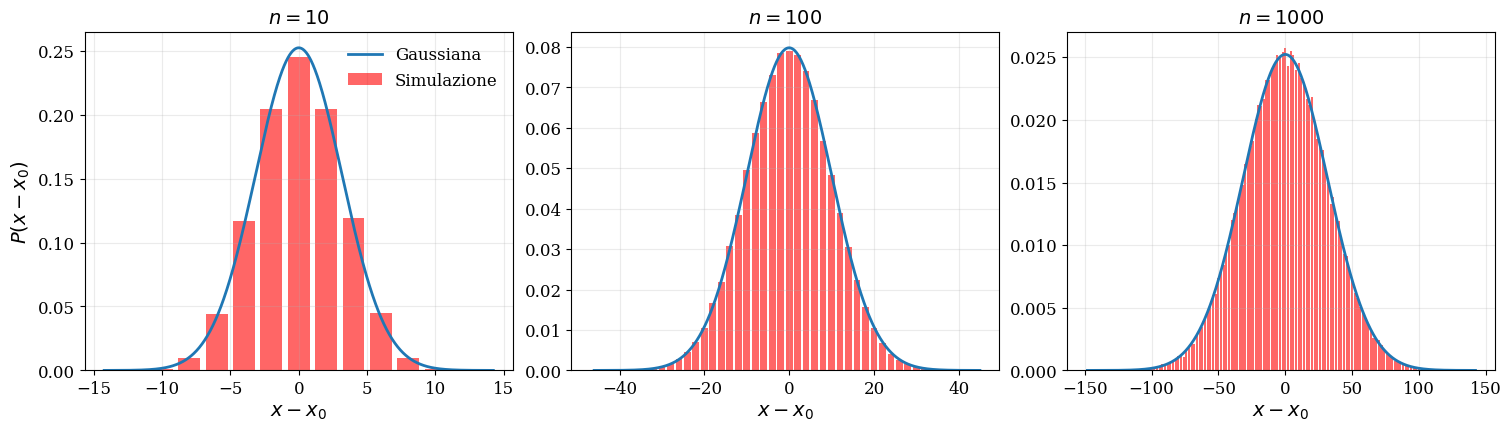

In [17]:
step_length = 1.0

plt.rcParams.update({
        "font.family": "serif",       
        "font.size": 12,              
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 16,
        "text.usetex": False          
    })

fig_prob, axes = plt.subplots(
    1,
    len(distributions),
    figsize=(15, 4.2),
    constrained_layout=True,
)

for ax, (n_steps, values) in zip(axes, distributions.items()):
    x = values["x"]
    probability = values["probability"]
    dx = values["dx"]

    theoretical_mean = 0.0
    theoretical_variance = n_steps * step_length**2
    sigma = np.sqrt(theoretical_variance)

    x_dense = np.linspace(
        min(x.min(), -4.5 * sigma),
        max(x.max(), 4.5 * sigma),
        1000,
    )

    gaussian_dense = gaussian_probability_mass(
        x_dense,
        theoretical_mean,
        theoretical_variance,
        dx,
    )

    ax.bar(x, probability, width=0.8 * dx, alpha=0.6, color="red", label="Simulazione")
    ax.plot(x_dense, gaussian_dense, linewidth=2, label="Gaussiana",
    )

    ax.set_title(rf"$n={n_steps}$")
    ax.set_xlabel(r"$x-x_0$")
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"$P(x-x_0)$")
axes[0].legend(frameon=False, loc="upper right")

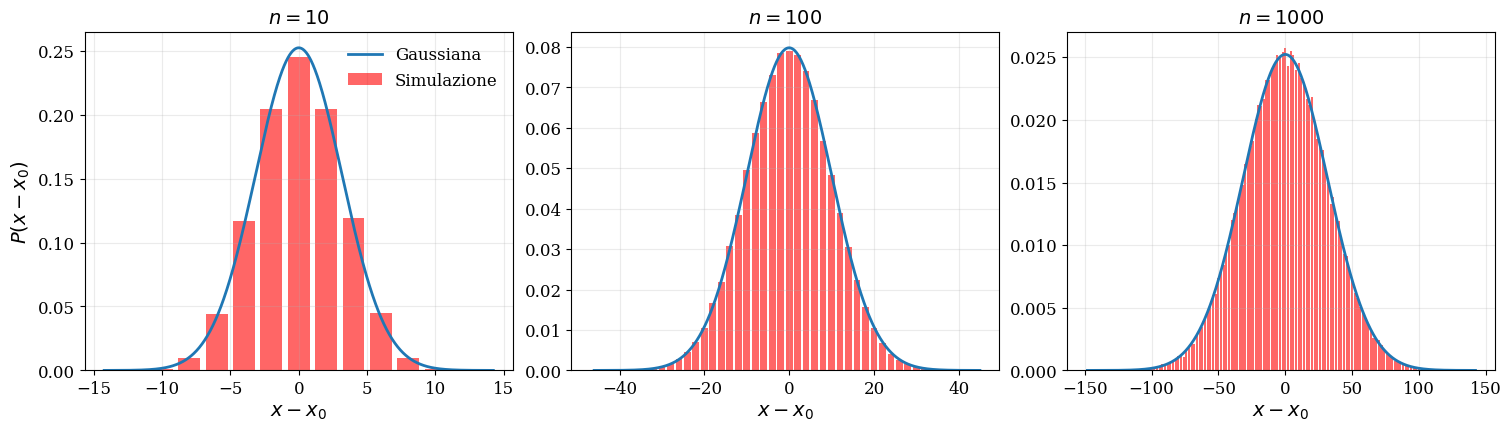

In [18]:
#| label: cell:res_random_walk_prob
fig_prob

Mostriamo diverse realizzazioni di un random walk 1D.

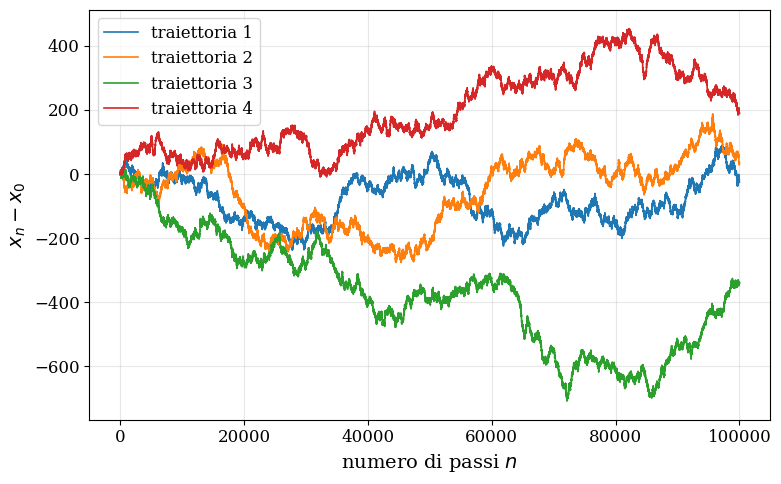

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri
n_steps = 100000
n_trajectories = 4
step_length = 1.0
seed = 6278328252

rng = np.random.default_rng(seed)

# Passi casuali: +a oppure -a
steps = rng.choice(
    [-step_length, step_length],
    size=(n_trajectories, n_steps),
)

# Aggiungiamo la posizione iniziale x_0 = 0
positions = np.zeros((n_trajectories, n_steps + 1))
positions[:, 1:] = np.cumsum(steps, axis=1)

time = np.arange(n_steps + 1)

fig_traj, ax = plt.subplots(figsize=(8, 5))

for i in range(n_trajectories):
    ax.plot(
        time,
        positions[i],
        linewidth=1.2,
        label=f"traiettoria {i + 1}",
    )

ax.set_xlabel("numero di passi $n$")
ax.set_ylabel(r"$x_n-x_0$")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

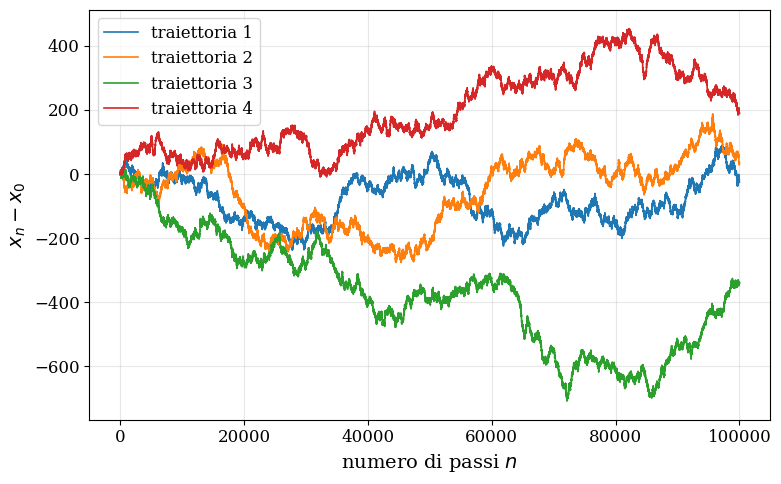

In [55]:
#| label: cell:res_random_walk_traj
fig_traj

Qui mostriamo come la media dell'MSD di un random walk 1D tende a una retta in scala doppio log

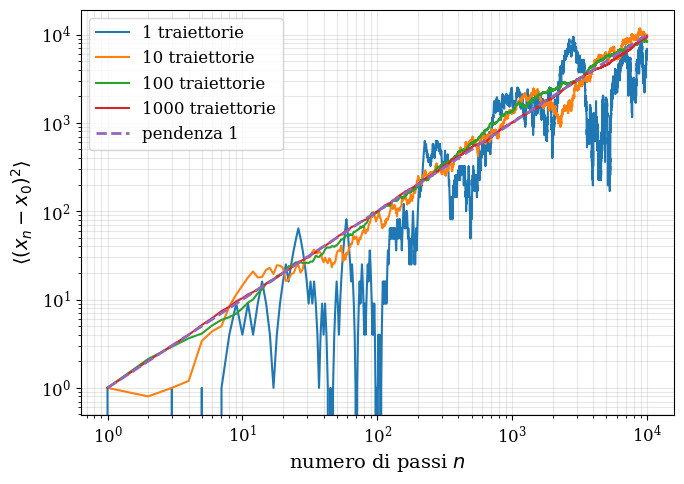

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri della simulazione
n_steps = 10_000
n_trajectories_list = [1, 10, 100, 1000]
step_length = 1.0
seed = 12345

rng = np.random.default_rng(seed)

time = np.arange(1, n_steps + 1)

fig_msd, ax = plt.subplots(figsize=(7, 5))

for n_trajectories in n_trajectories_list:
    # Passi casuali: +a oppure -a con uguale probabilità
    steps = rng.choice(
        [-step_length, step_length],
        size=(n_trajectories, n_steps),
    )

    # Posizioni lungo ciascuna traiettoria
    positions = np.cumsum(steps, axis=1)

    # MSD mediato sulle traiettorie
    msd = np.mean(positions**2, axis=0)

    if n_trajectories_list == 1:
        label = f"{n_trajectories} traiettoria"
    else:
        label = f"{n_trajectories} traiettorie"
    ax.loglog(
        time,
        msd,
        label=label,
    )

# Retta di riferimento con pendenza 1
reference = step_length**2 * time

ax.loglog(
    time,
    reference,
    "--",
    linewidth=2,
    label="pendenza 1",
)

ax.set_xlabel("numero di passi $n$")
ax.set_ylabel(r"$\langle (x_n-x_0)^2 \rangle$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()

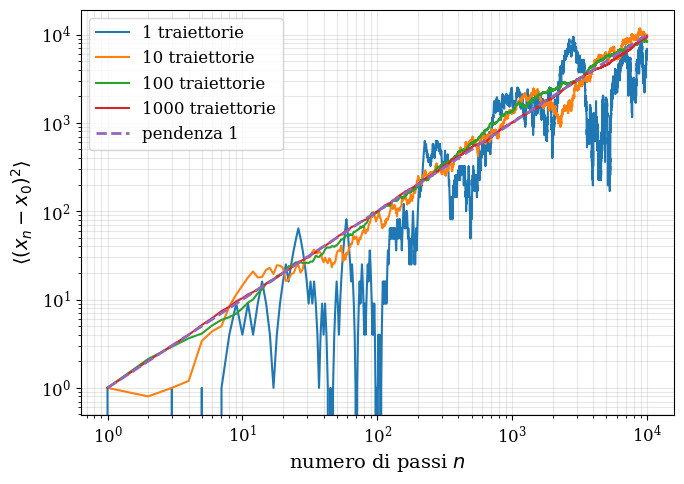

In [32]:
#| label: cell:res_random_walk_msd
fig_msd

# Equazione di Langevin

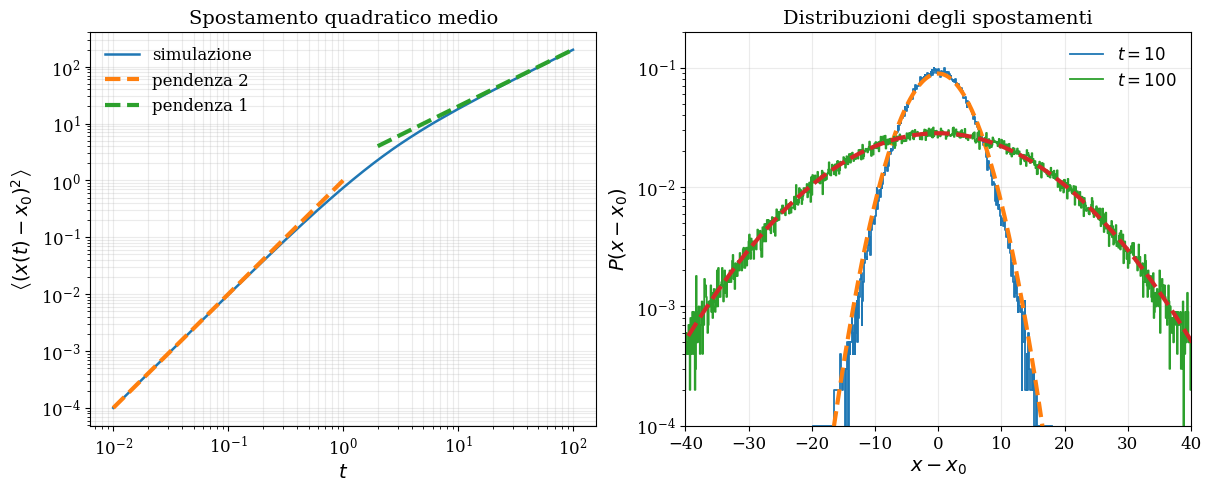

In [87]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# Parametri
dt = 0.01
mass = 1.0
gamma = 1.0
kT = 1.0

tau_v = mass / gamma
D = kT / gamma

steps = [1000, 10000]

def gaussian(x, mean, variance):
    return (
        np.exp(-(x - mean) ** 2 / (2.0 * variance))
        / np.sqrt(2.0 * np.pi * variance)
    )


fig_langevin, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
    constrained_layout=True,
)

ax_msd, ax_prob = axes


# ============================================================
# Pannello sinistro: MSD
# ============================================================

time, msd = np.loadtxt(
    BASE_FOLDER / "langevin_msd.dat",
    unpack=True,
)

# Eliminiamo t = 0 per poter usare gli assi logaritmici.
mask = (time > 0.0) & (msd > 0.0)
time_plot = time[mask]
msd_plot = msd[mask]

ax_msd.loglog(
    time_plot,
    msd_plot,
    linewidth=1.8,
    label="simulazione",
)

# Retta di pendenza 2, normalizzata nella regione balistica.
t_ballistic = time_plot[time_plot <= 1]
ax_msd.loglog(
    t_ballistic,
    (kT / mass) * t_ballistic**2,
    "--",
    linewidth=3,
    label="pendenza 2",
)

# Retta di pendenza 1, normalizzata nella regione diffusiva.
t_diffusive = time_plot[time_plot >= 2.0]
ax_msd.loglog(
    t_diffusive,
    2.0 * D * t_diffusive,
    "--",
    linewidth=3,
    label="pendenza 1",
)

ax_msd.set_xlabel(r"$t$")
ax_msd.set_ylabel(
    r"$\left\langle (x(t)-x_0)^2 \right\rangle$"
)
ax_msd.set_title("Spostamento quadratico medio")
ax_msd.grid(True, which="both", alpha=0.25)
ax_msd.legend(frameon=False)


# ============================================================
# Pannello destro: distribuzioni degli spostamenti
# ============================================================

for n_steps in steps:
    filename = BASE_FOLDER / f"langevin_prob_{n_steps}.dat"

    x, probability = np.loadtxt(
        filename,
        unpack=True,
    )

    # I file contengono probabilità per bin.
    dx = np.median(np.diff(x))

    normalization = np.sum(probability)
    probability = probability / normalization

    mean = 0
    D = 1.0
    t = n_steps * dt
    variance = 2 * D * t

    # Convertiamo la probabilità per bin in densità.
    density = probability / dx

    x_dense = np.linspace(
        x.min(),
        x.max(),
        1000,
    )

    gaussian_density = gaussian(
        x_dense,
        mean,
        variance,
    )

    time_value = n_steps * dt

    ax_prob.step(
        x,
        density,
        where="mid",
        linewidth=1.3,
        label=rf"$t={time_value:g}$",
    )

    ax_prob.plot(
        x_dense,
        gaussian_density,
        "--",
        linewidth=3,
    )

ax_prob.set_xlabel(r"$x-x_0$")
ax_prob.set_ylabel(r"$P(x-x_0)$")
ax_prob.set_title("Distribuzioni degli spostamenti")
ax_prob.set_yscale("log")
ax_prob.set_xlim(-40, 40)
ax_prob.set_ylim(1e-4, 0.2)
ax_prob.grid(alpha=0.25)
ax_prob.legend(frameon=False)


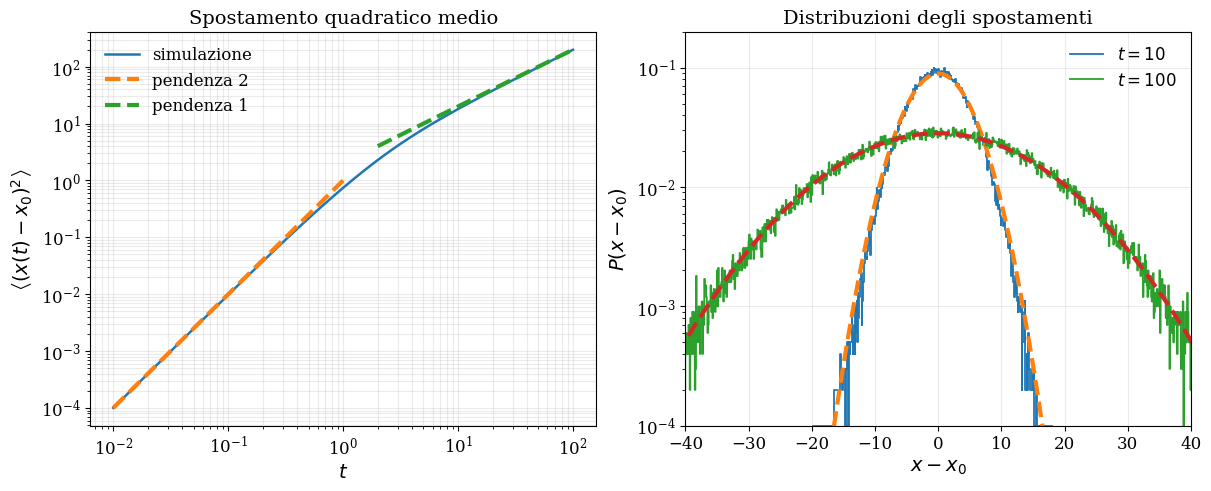

In [88]:
#| label: cell:res_langevin
fig_langevin